In [ ]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size':        16,
    'axes.titlesize':   18,
    'axes.labelsize':   16,
    'xtick.labelsize':  14,
    'ytick.labelsize':  14,
    'legend.fontsize':  18,
})

# Raw benchmark results: one row per (device, wraparound, circuit, config, seed)
df  = pd.read_csv('Results/paper.csv')   # SNAIL topologies
dft = pd.read_csv('Results/ibm.csv')     # IBM backend: Brooklyn (65q)

_cfg_rename = {'Standard SABRE': 'SABRE', 'Standard MIRAGE': 'MIRAGE'}
df['config']  = df['config'].replace(_cfg_rename)
dft['config'] = dft['config'].replace(_cfg_rename)

# Combine device + wraparound flag into a single topology label
df['topo']  = df['device'] + df['wraparound'].map({True: '_wrap', False: ''})
dft['topo'] = dft['device']  # fake_brooklyn

CONFIG_ORDER = ['SABRE', 'FASST', 'MIRAGE', 'FINESSE']
CFG_COLORS   = ['#4C72B0', '#1B6B3A', '#DD8452', '#7B1D1D']

# All 8 SNAIL topologies (4 module types × wrapped/non-wrapped)
TOPO_ORDER = [
    'square_ring', 'square_ring_wrap',
    'square_ring_diag', 'square_ring_diag_wrap',
    'square_ring_full', 'square_ring_full_wrap',
    'pentagon_ring', 'pentagon_ring_wrap',
]
TOPO_LABELS = {
    'square_ring':           '4-qubit, 4-edge module',
    'square_ring_wrap':      '4-qubit, 4-edge module (wrapped)',
    'square_ring_diag':      '4-qubit, 5-edge module',
    'square_ring_diag_wrap': '4-qubit, 5-edge module (wrapped)',
    'square_ring_full':      '4-qubit, 6-edge module',
    'square_ring_full_wrap': '4-qubit, 6-edge module (wrapped)',
    'pentagon_ring':         '5-qubit, 7-edge module',
    'pentagon_ring_wrap':    '5-qubit, 7-edge module (wrapped)',
}

IBM_TOPO_ORDER = ['fake_brooklyn']
IBM_TOPO_LABELS = {
    'fake_brooklyn': 'Brooklyn (65q, std=0.009)',
}
IBM_TOPO_COLORS = ['#B85C38']

# Updated 18-circuit suite: 6 per size band (8–14q, 15–21q, 22–32q)
CIRCUIT_ORDER = [
    # 8–14q
    'qpeexact_n8', 'wstate_n8', 'qft_n10', 'ae_n10', 'ghz_n10', 'vqe_two_local_n10',
    # 15–21q
    'seca_n11', 'multiplier_n15', 'dnn_n16', 'qec9xz_n17', 'square_root_n18', 'bv_n19',
    # 22–32q
    'qft_n24', 'qaoa_n25_p3', 'ising_n26', 'qft_n32', 'qaoa_n32_p3', 'random_n32_d50',
]
CIRC_LABELS = {
    'qpeexact_n8':       'QPE\n(n8)',
    'wstate_n8':         'W-st\n(n8)',
    'qft_n10':           'QFT\n(n10)',
    'ae_n10':            'AE\n(n10)',
    'ghz_n10':           'GHZ\n(n10)',
    'vqe_two_local_n10': 'VQE\n(n10)',
    'seca_n11':          'SECA\n(n11)',
    'multiplier_n15':    'Mult\n(n15)',
    'dnn_n16':           'DNN\n(n16)',
    'qec9xz_n17':        'QEC\n(n17)',
    'square_root_n18':   '√n\n(n18)',
    'bv_n19':            'BV\n(n19)',
    'qft_n24':           'QFT\n(n24)',
    'qaoa_n25_p3':       'QAOA\n(n25)',
    'ising_n26':         'Ising\n(n26)',
    'qft_n32':           'QFT\n(n32)',
    'qaoa_n32_p3':       'QAOA\n(n32)',
    'random_n32_d50':    'Rand\n(n32)',
}

# Two post-selection strategies:
#
# "native": each config selects by what it actually optimises.
#   SABRE  → min swaps  (SABRE paper objective)
#   MIRAGE → min depth  (MIRAGE paper objective)
#   FASST/FINESSE → min lf_cost  (our objective)
#   Use for swap/depth metric tables.
#
# "lf": all configs select the trial with lowest lf_cost.
#   Fair comparison when the reported metric is lf_cost.
#   Use for all lf_cost metric tables and plots.

POST_SELECT_NATIVE = {
    'SABRE':   'swaps',
    'MIRAGE':  'depth',
    'FASST':   'lf_cost',
    'FINESSE': 'lf_cost',
}
POST_SELECT_LF = {cfg: 'lf_cost' for cfg in CONFIG_ORDER}

def post_select(df, post_select_map, groupby_cols=('topo', 'circuit')):
    """For each (groupby_cols, config) group, keep the single row with the
    lowest value of that config's post-selection column."""
    frames = []
    for cfg, col in post_select_map.items():
        sub = df[df.config == cfg]
        if sub.empty:
            continue
        best_idx = sub.groupby(list(groupby_cols))[col].idxmin()
        frames.append(sub.loc[best_idx])
    return pd.concat(frames).reset_index(drop=True)

# Filter: only topologies/circuits actually present in the data
present_topos = [t for t in TOPO_ORDER if t in df['topo'].values]
nowrap_topos  = [t for t in present_topos if not t.endswith('_wrap')]
present_circs = [c for c in CIRCUIT_ORDER if c in df['circuit'].values]
present_ibm   = [t for t in IBM_TOPO_ORDER if t in dft['topo'].values]

COMPARE_CFGS   = [c for c in CONFIG_ORDER if c != 'SABRE']
COMPARE_COLORS = [c for cfg, c in zip(CONFIG_ORDER, CFG_COLORS) if cfg != 'SABRE']

_snail = df[~df['wraparound'] & df['topo'].isin(nowrap_topos)]
_ibm   = dft[dft['topo'].isin(present_ibm)]

# Native post-selection (each config optimises its own metric)
ps_df_native  = post_select(_snail, POST_SELECT_NATIVE)
ps_dft_native = post_select(_ibm,   POST_SELECT_NATIVE, groupby_cols=('topo', 'circuit'))

# lf_cost post-selection (all configs show best achievable lf_cost)
ps_df  = post_select(_snail, POST_SELECT_LF)
ps_dft = post_select(_ibm,   POST_SELECT_LF, groupby_cols=('topo', 'circuit'))

print(f'Circuits ({len(present_circs)}): {present_circs}')
print(f'Non-wrapped SNAIL topologies ({len(nowrap_topos)}): {nowrap_topos}')
print(f'IBM topologies: {present_ibm}')
print(f'IBM circuits:   {sorted(dft.circuit.unique())}')

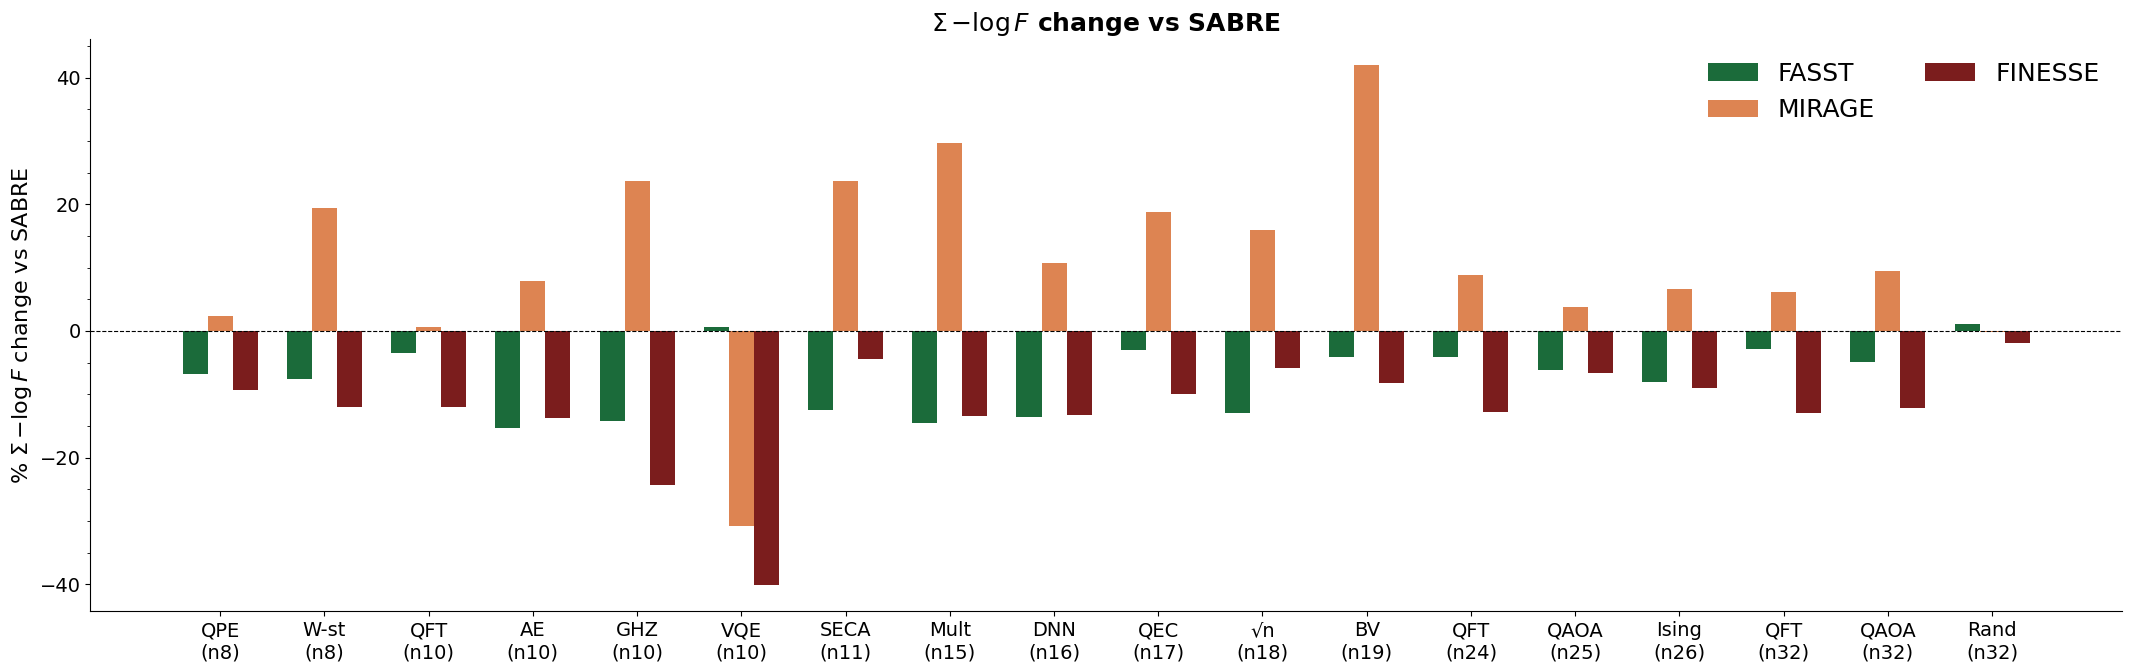

Saved → figures/fig_lf_change_per_circ_native.pdf


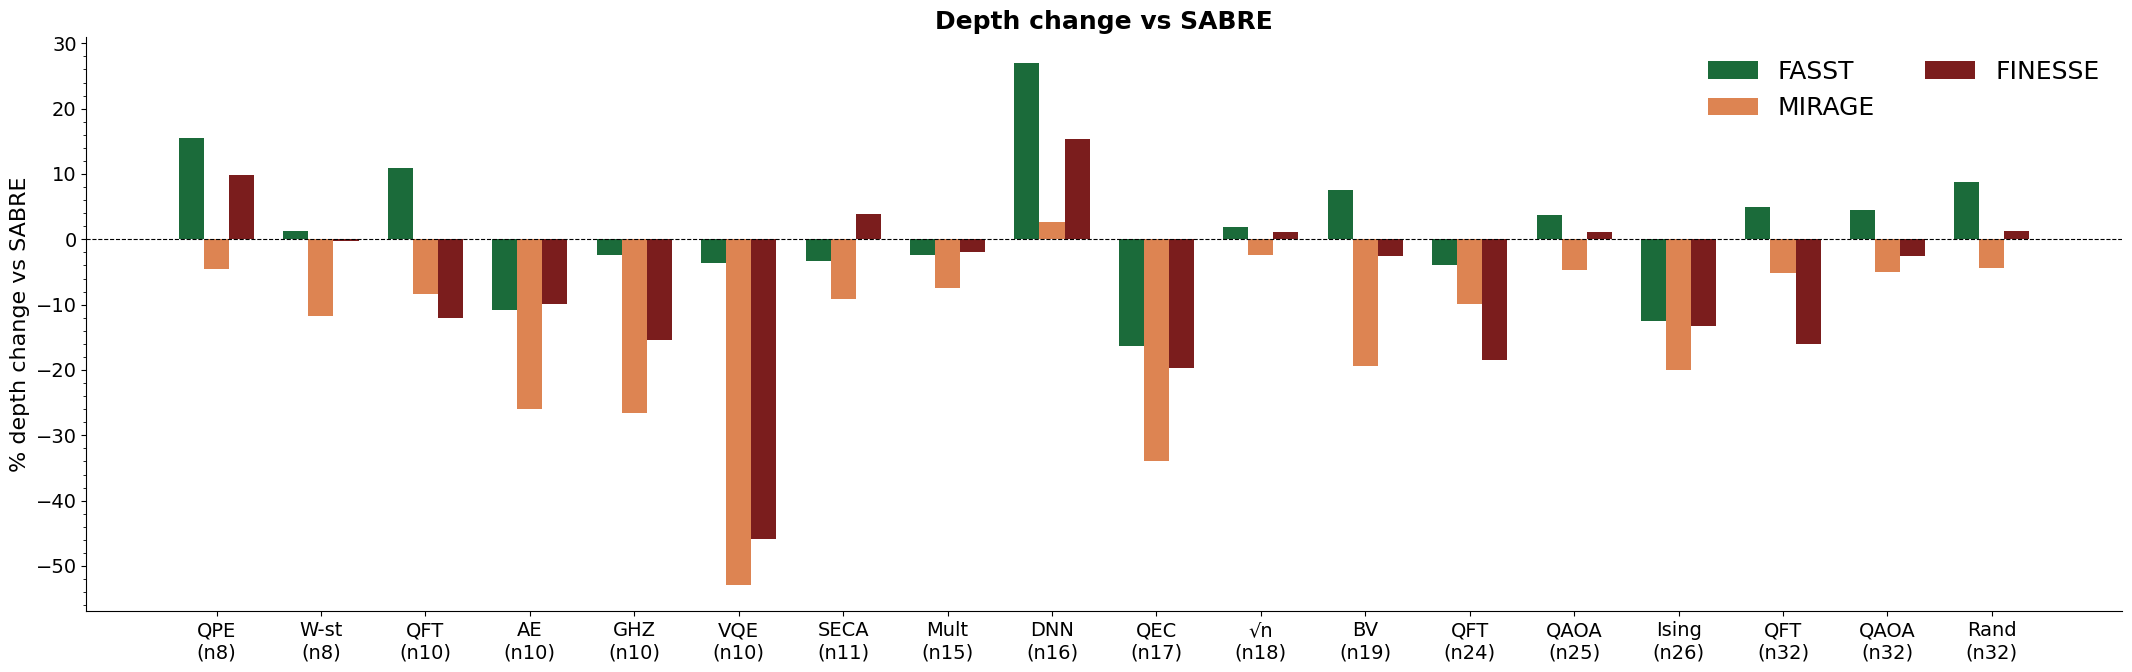

Saved → figures/fig_depth_change_per_circ_native.pdf


In [2]:
# ── Figs: % change vs SABRE for lf_cost, depth ────────────────────────────────
# → fig_lf_change_per_circ_native.pdf
# → fig_depth_change_per_circ_native.pdf
#
# % change = 100 * (algo - SABRE) / SABRE for all metrics.
# Negative = algo is better than SABRE; positive = algo is worse.
# Averaged across the 4 non-wrapped SNAIL topologies per circuit.

circs = [c for c in CIRCUIT_ORDER if c in ps_df_native['circuit'].values]
xs    = np.arange(len(circs))
n_cfg = len(COMPARE_CFGS)
w     = 0.72 / n_cfg

PANELS = [
    ('lf_cost', r'% $\Sigma\,{-}\log F$ change vs SABRE', r'$\Sigma\,{-}\log F$ change vs SABRE', 'fig_lf_change_per_circ_native.pdf'),
    ('depth',   '% depth change vs SABRE',                 'Depth change vs SABRE',                'fig_depth_change_per_circ_native.pdf'),
]

for col, ylabel, title, fname in PANELS:
    fig, ax = plt.subplots(figsize=(max(10, len(circs) * 1.2), 7))
    ax.set_title(title, fontweight='bold')

    for k, (cfg, color) in enumerate(zip(COMPARE_CFGS, COMPARE_COLORS)):
        vals = []
        for circ in circs:
            pcts = []
            for topo in nowrap_topos:
                b = ps_df_native[(ps_df_native.topo==topo)&(ps_df_native.circuit==circ)&(ps_df_native.config=='SABRE')]
                t = ps_df_native[(ps_df_native.topo==topo)&(ps_df_native.circuit==circ)&(ps_df_native.config==cfg)]
                if len(b) and len(t) and float(b[col].values[0]) > 0:
                    pcts.append(100 * (float(t[col].values[0]) - float(b[col].values[0])) / float(b[col].values[0]))
            vals.append(np.mean(pcts) if pcts else 0.0)
        ax.bar(xs + (k - (n_cfg-1)/2)*w, vals, w, color=color, label=cfg)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(xs)
    ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs])
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right', frameon=False, ncol=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}')


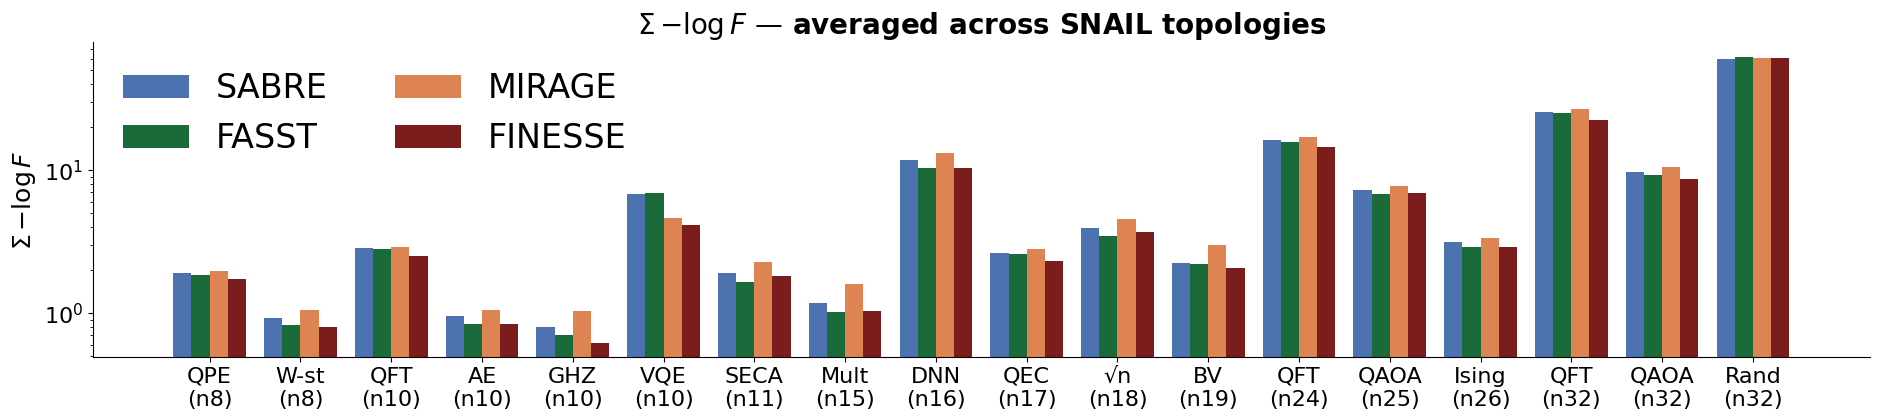

Saved → figures/fig_lf_abs_per_circ_native.pdf


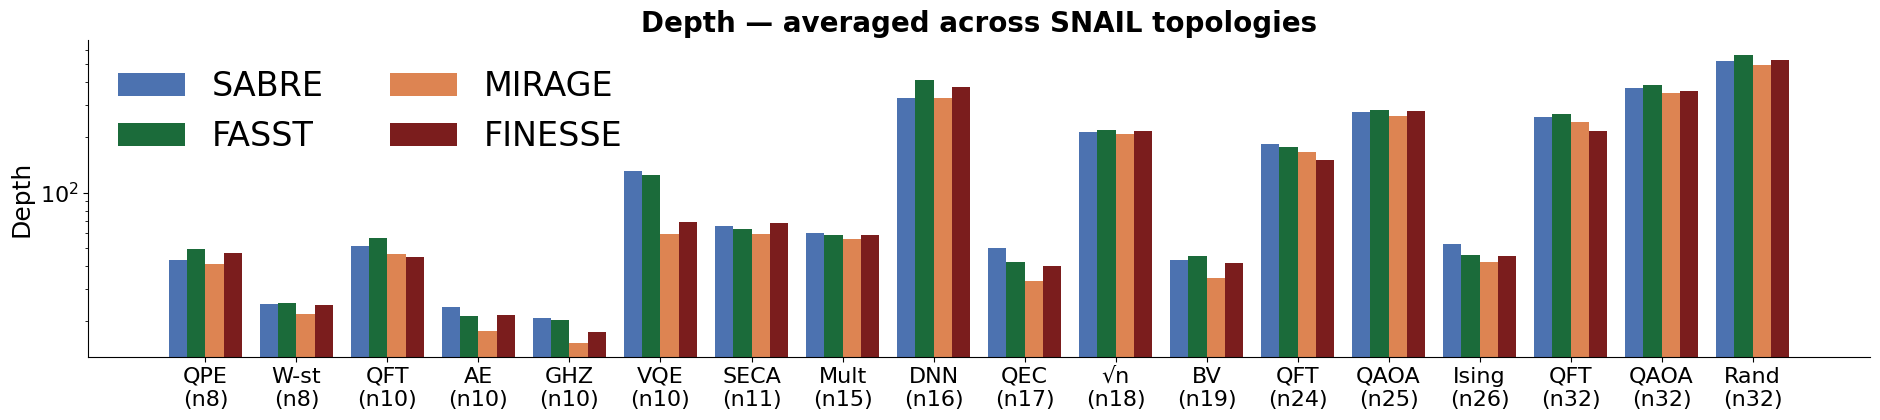

Saved → figures/fig_depth_abs_per_circ_native.pdf


In [3]:
# ── Figs: absolute values — all 4 configs, averaged across SNAIL topologies ────
# → fig_lf_abs_per_circ_native.pdf  /  fig_depth_abs_per_circ_native.pdf

circs  = [c for c in CIRCUIT_ORDER if c in ps_df_native['circuit'].values]
xs     = np.arange(len(circs))
n_cfg4 = len(CONFIG_ORDER)
w4     = 0.80 / n_cfg4

ABS_PANELS = [
    ('lf_cost', r'$\Sigma\,{-}\log F$',  r'$\Sigma\,{-}\log F$ — averaged across SNAIL topologies', 'fig_lf_abs_per_circ_native.pdf'),
    ('depth',   'Depth',                     'Depth — averaged across SNAIL topologies',                   'fig_depth_abs_per_circ_native.pdf'),
]

_rc_abs = {'font.size': 100, 'axes.titlesize': 20, 'axes.labelsize': 18,
           'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 24}

for col, ylabel, title, fname in ABS_PANELS:
    with plt.rc_context(_rc_abs):
        fig, ax = plt.subplots(figsize=(max(10, len(circs) * 1.2), 7))
        ax.set_title(title, fontweight='bold')

        for k, (cfg, color) in enumerate(zip(CONFIG_ORDER, CFG_COLORS)):
            vals = []
            for circ in circs:
                topo_vals = []
                for topo in nowrap_topos:
                    r = ps_df_native[(ps_df_native.topo==topo)&(ps_df_native.circuit==circ)&(ps_df_native.config==cfg)]
                    if len(r):
                        topo_vals.append(float(r[col].values[0]))
                vals.append(np.mean(topo_vals) if topo_vals else np.nan)
            ax.bar(xs + (k - (n_cfg4-1)/2)*w4, vals, w4, color=color, label=cfg)

        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
        ax.yaxis.set_minor_locator(mticker.LogLocator(subs='auto'))
        ax.set_xticks(xs)
        ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs])
        ax.set_ylabel(ylabel)
        ax.legend(loc='upper left', frameon=False, ncol=2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig(f'figures/{fname}', bbox_inches='tight')
        plt.show()
        print(f'Saved → figures/{fname}')

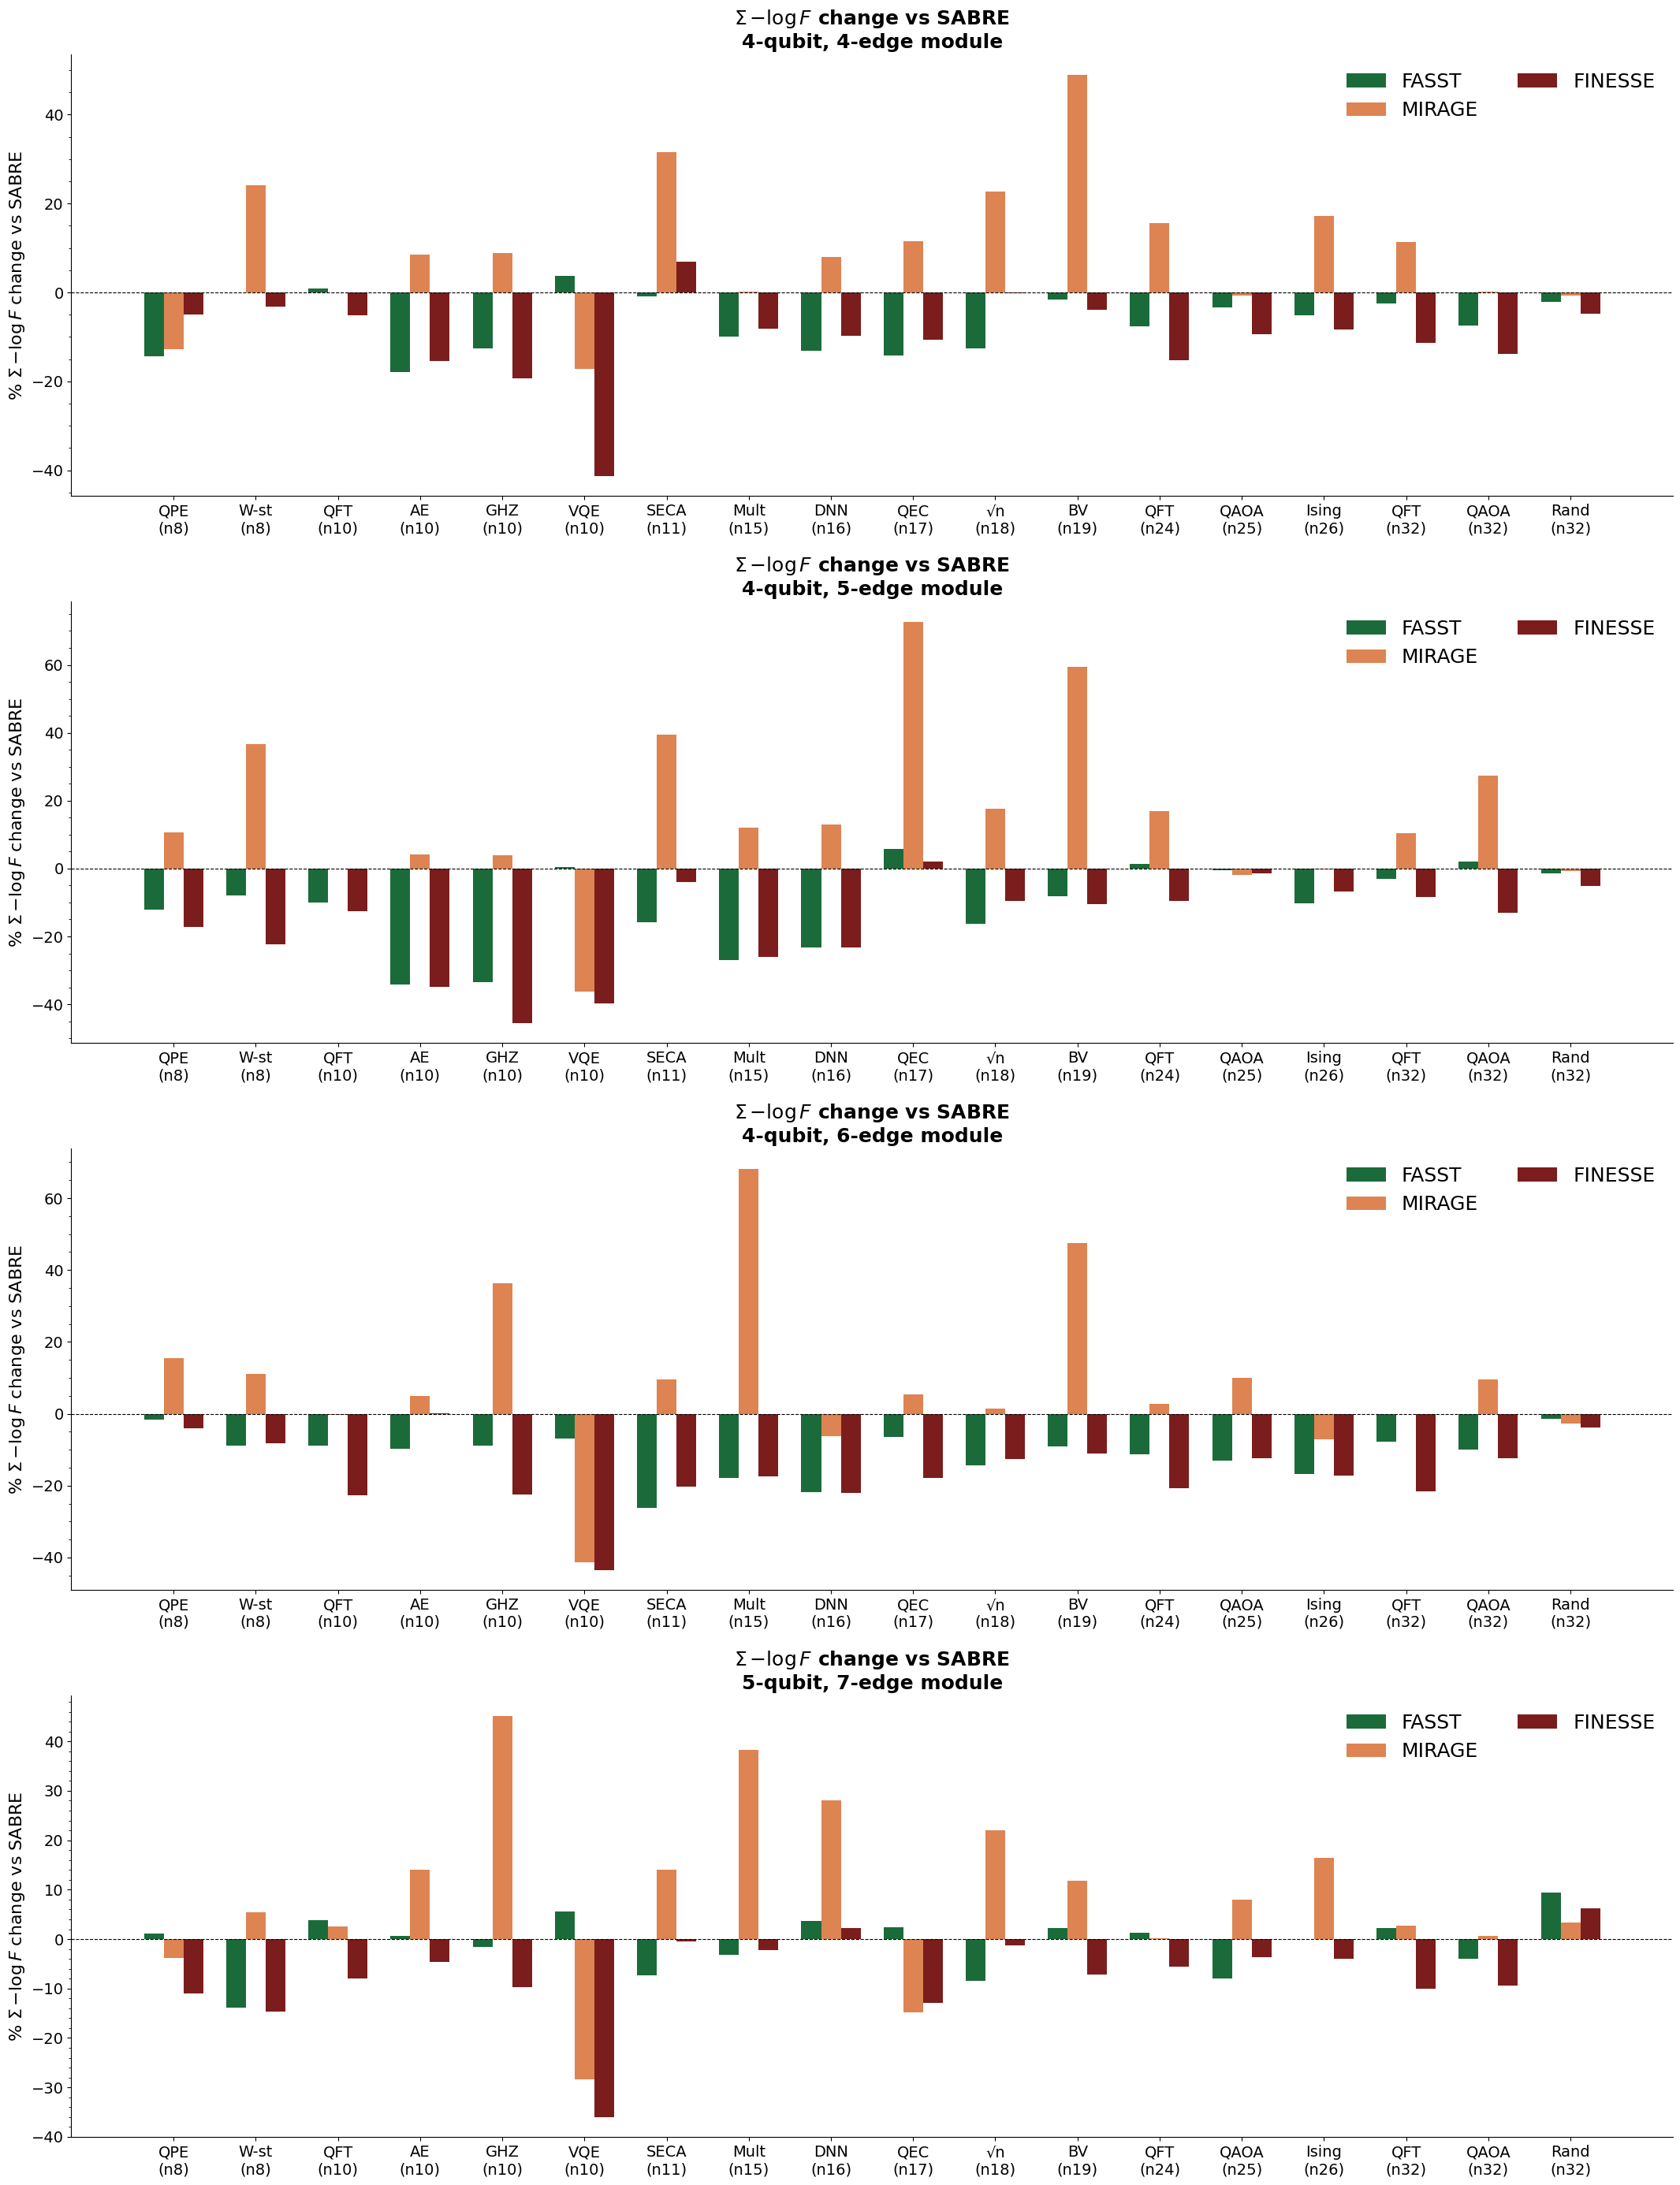

Saved → figures/fig_lf_change_per_circ_by_topo.pdf


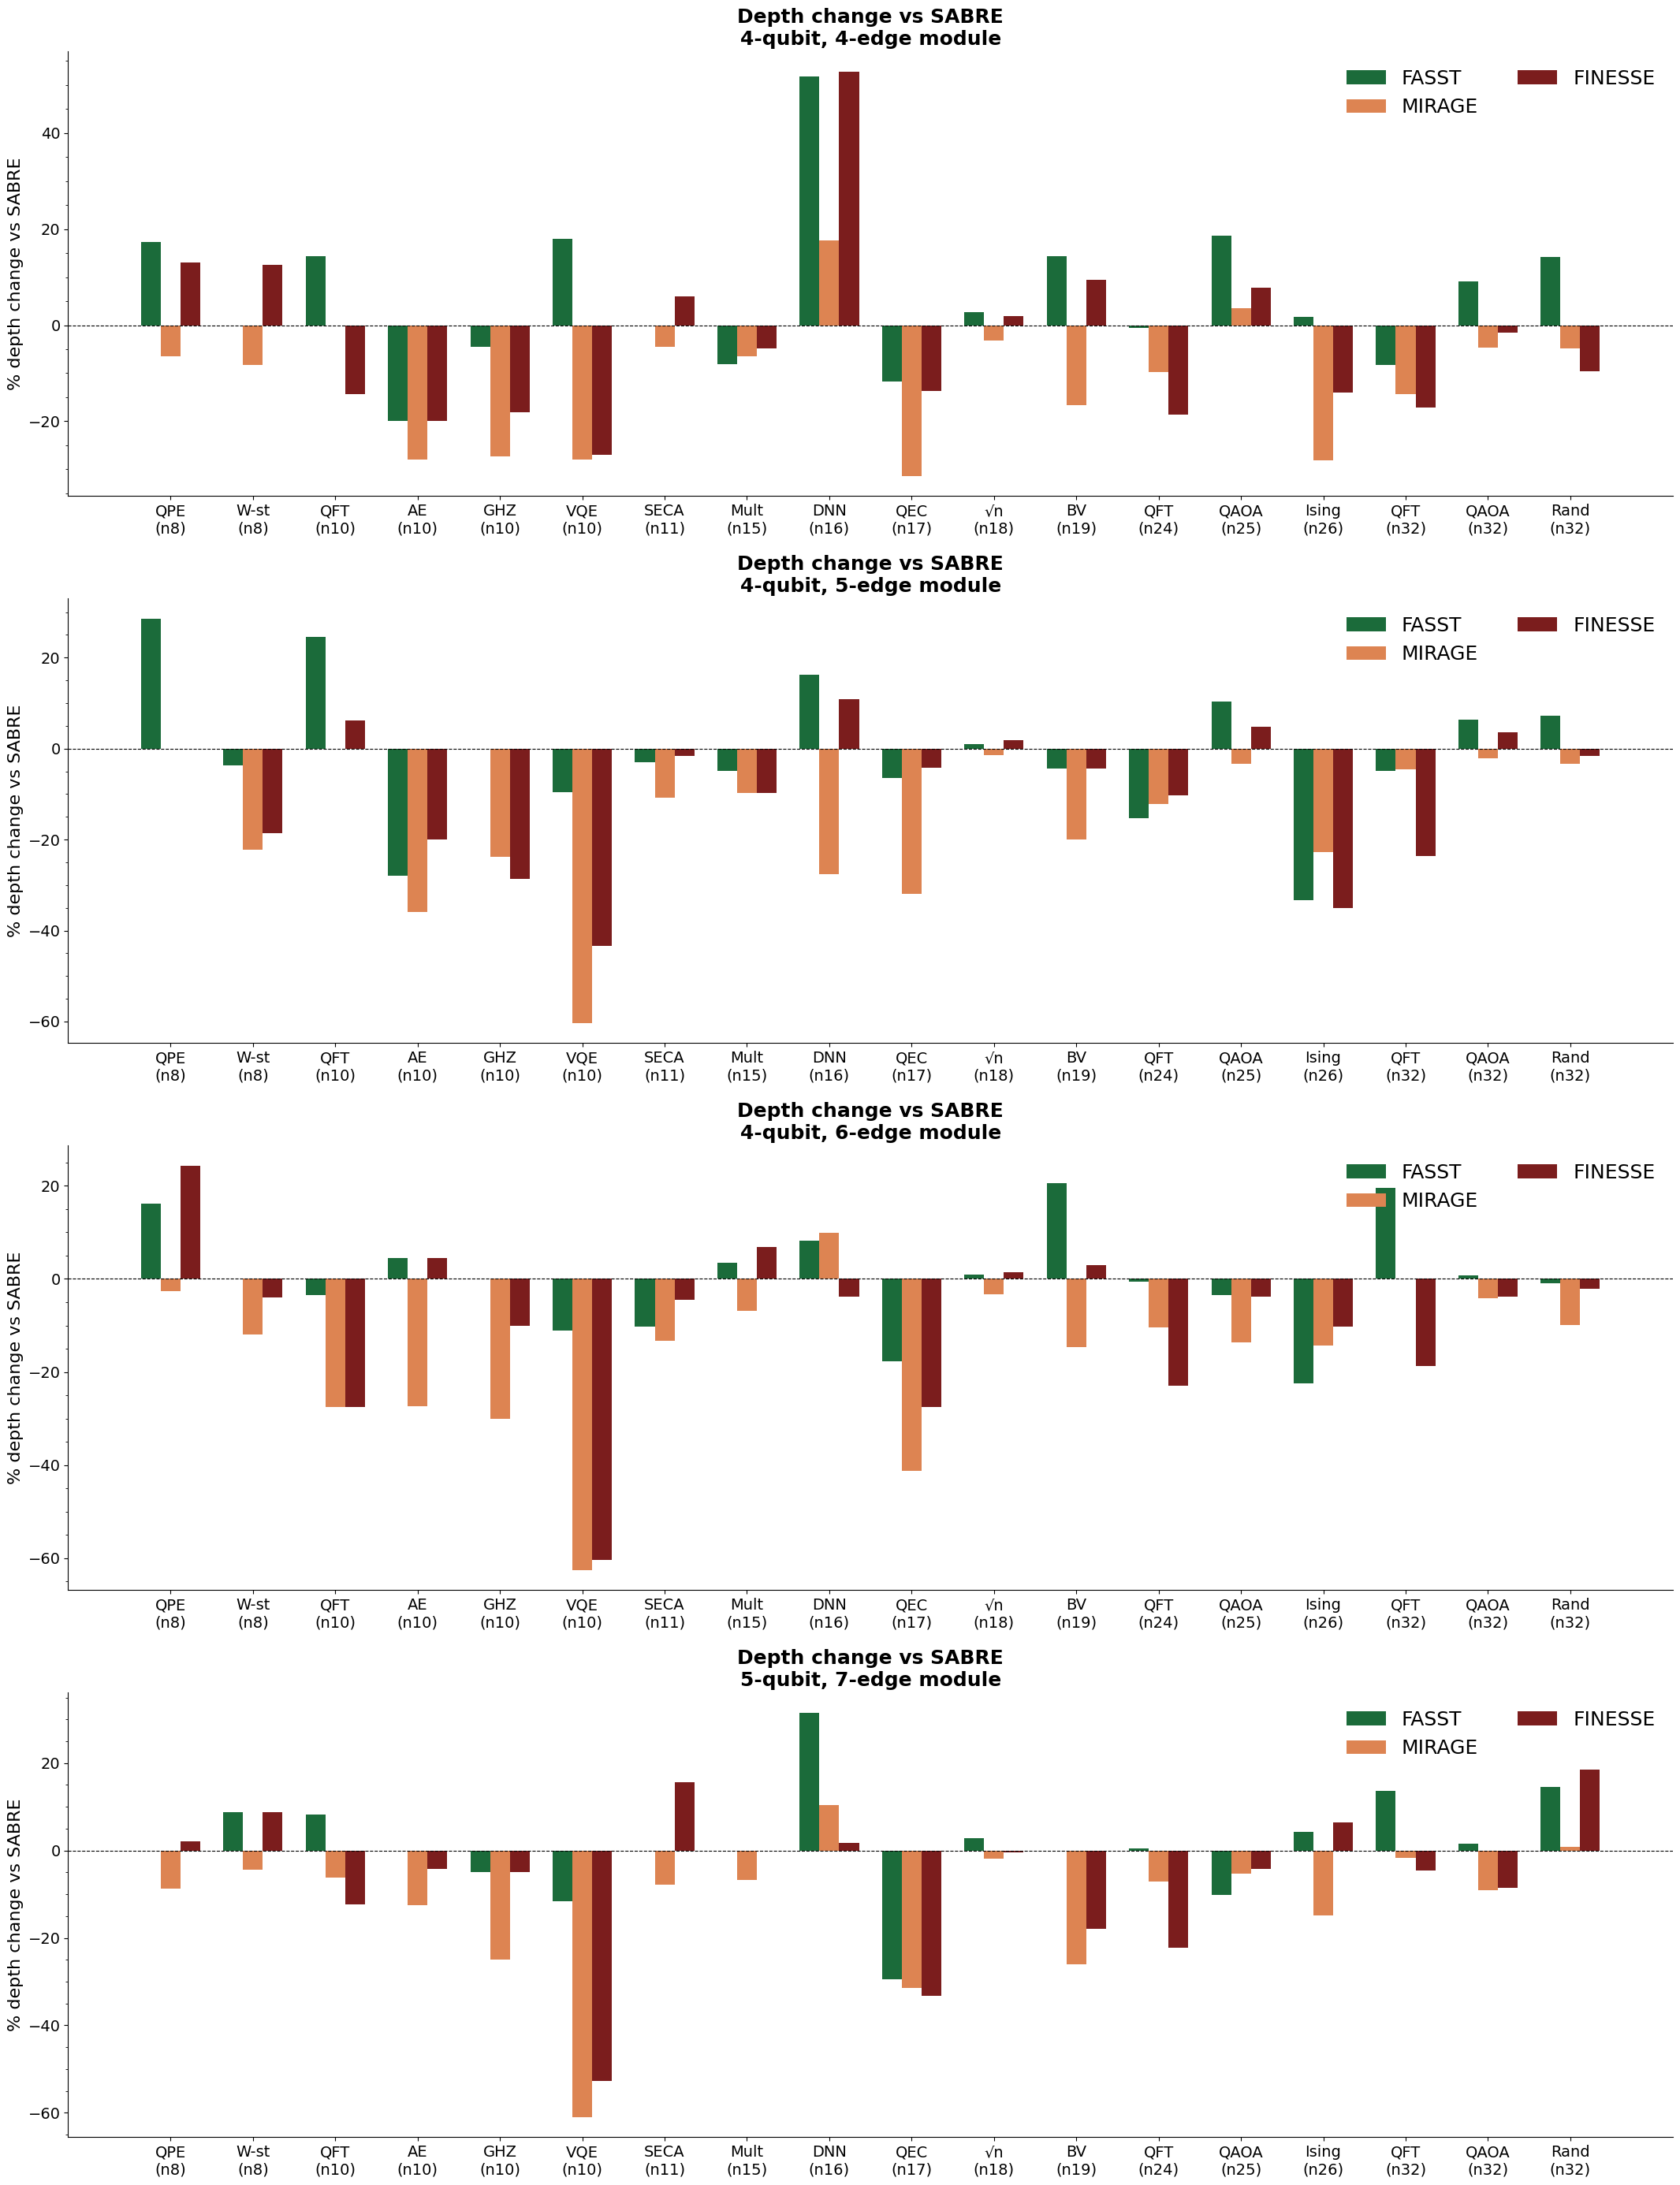

Saved → figures/fig_depth_change_per_circ_by_topo.pdf


In [4]:
# ── Figs: % change vs SABRE — per topology (no averaging) ──────────────────────
# → fig_lf_change_per_circ_{topo}.pdf
# → fig_depth_change_per_circ_{topo}.pdf
#
# Same computation as the averaged plots, but one figure per SNAIL topology.

circs = [c for c in CIRCUIT_ORDER if c in ps_df_native['circuit'].values]
xs    = np.arange(len(circs))
n_cfg = len(COMPARE_CFGS)
w     = 0.72 / n_cfg

PANELS = [
    ('lf_cost', r'% $\Sigma\,{-}\log F$ change vs SABRE', r'$\Sigma\,{-}\log F$ change vs SABRE', 'fig_lf_change_per_circ'),
    ('depth',   '% depth change vs SABRE',                 'Depth change vs SABRE',                'fig_depth_change_per_circ'),
]

for col, ylabel, title_base, fname_base in PANELS:
    n_topos = len(nowrap_topos)
    ncols = 1
    nrows = n_topos
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(max(10, len(circs) * 1.2), 7 * nrows),
                             sharey=False)
    axes = axes.flatten()

    for ax_idx, topo in enumerate(nowrap_topos):
        ax = axes[ax_idx]
        ax.set_title(f'{title_base}\n{TOPO_LABELS.get(topo, topo)}', fontweight='bold')

        for k, (cfg, color) in enumerate(zip(COMPARE_CFGS, COMPARE_COLORS)):
            vals = []
            for circ in circs:
                b = ps_df_native[(ps_df_native.topo==topo)&(ps_df_native.circuit==circ)&(ps_df_native.config=='SABRE')]
                t = ps_df_native[(ps_df_native.topo==topo)&(ps_df_native.circuit==circ)&(ps_df_native.config==cfg)]
                if len(b) and len(t) and float(b[col].values[0]) > 0:
                    vals.append(100 * (float(t[col].values[0]) - float(b[col].values[0])) / float(b[col].values[0]))
                else:
                    vals.append(0.0)
            ax.bar(xs + (k - (n_cfg-1)/2)*w, vals, w, color=color, label=cfg)

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(xs)
        ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs])
        ax.set_ylabel(ylabel)
        ax.legend(loc='upper right', frameon=False, ncol=2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

    # Hide any unused subplots
    for ax_idx in range(len(nowrap_topos), len(axes)):
        axes[ax_idx].set_visible(False)

    fname = f'{fname_base}_by_topo.pdf'
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}')


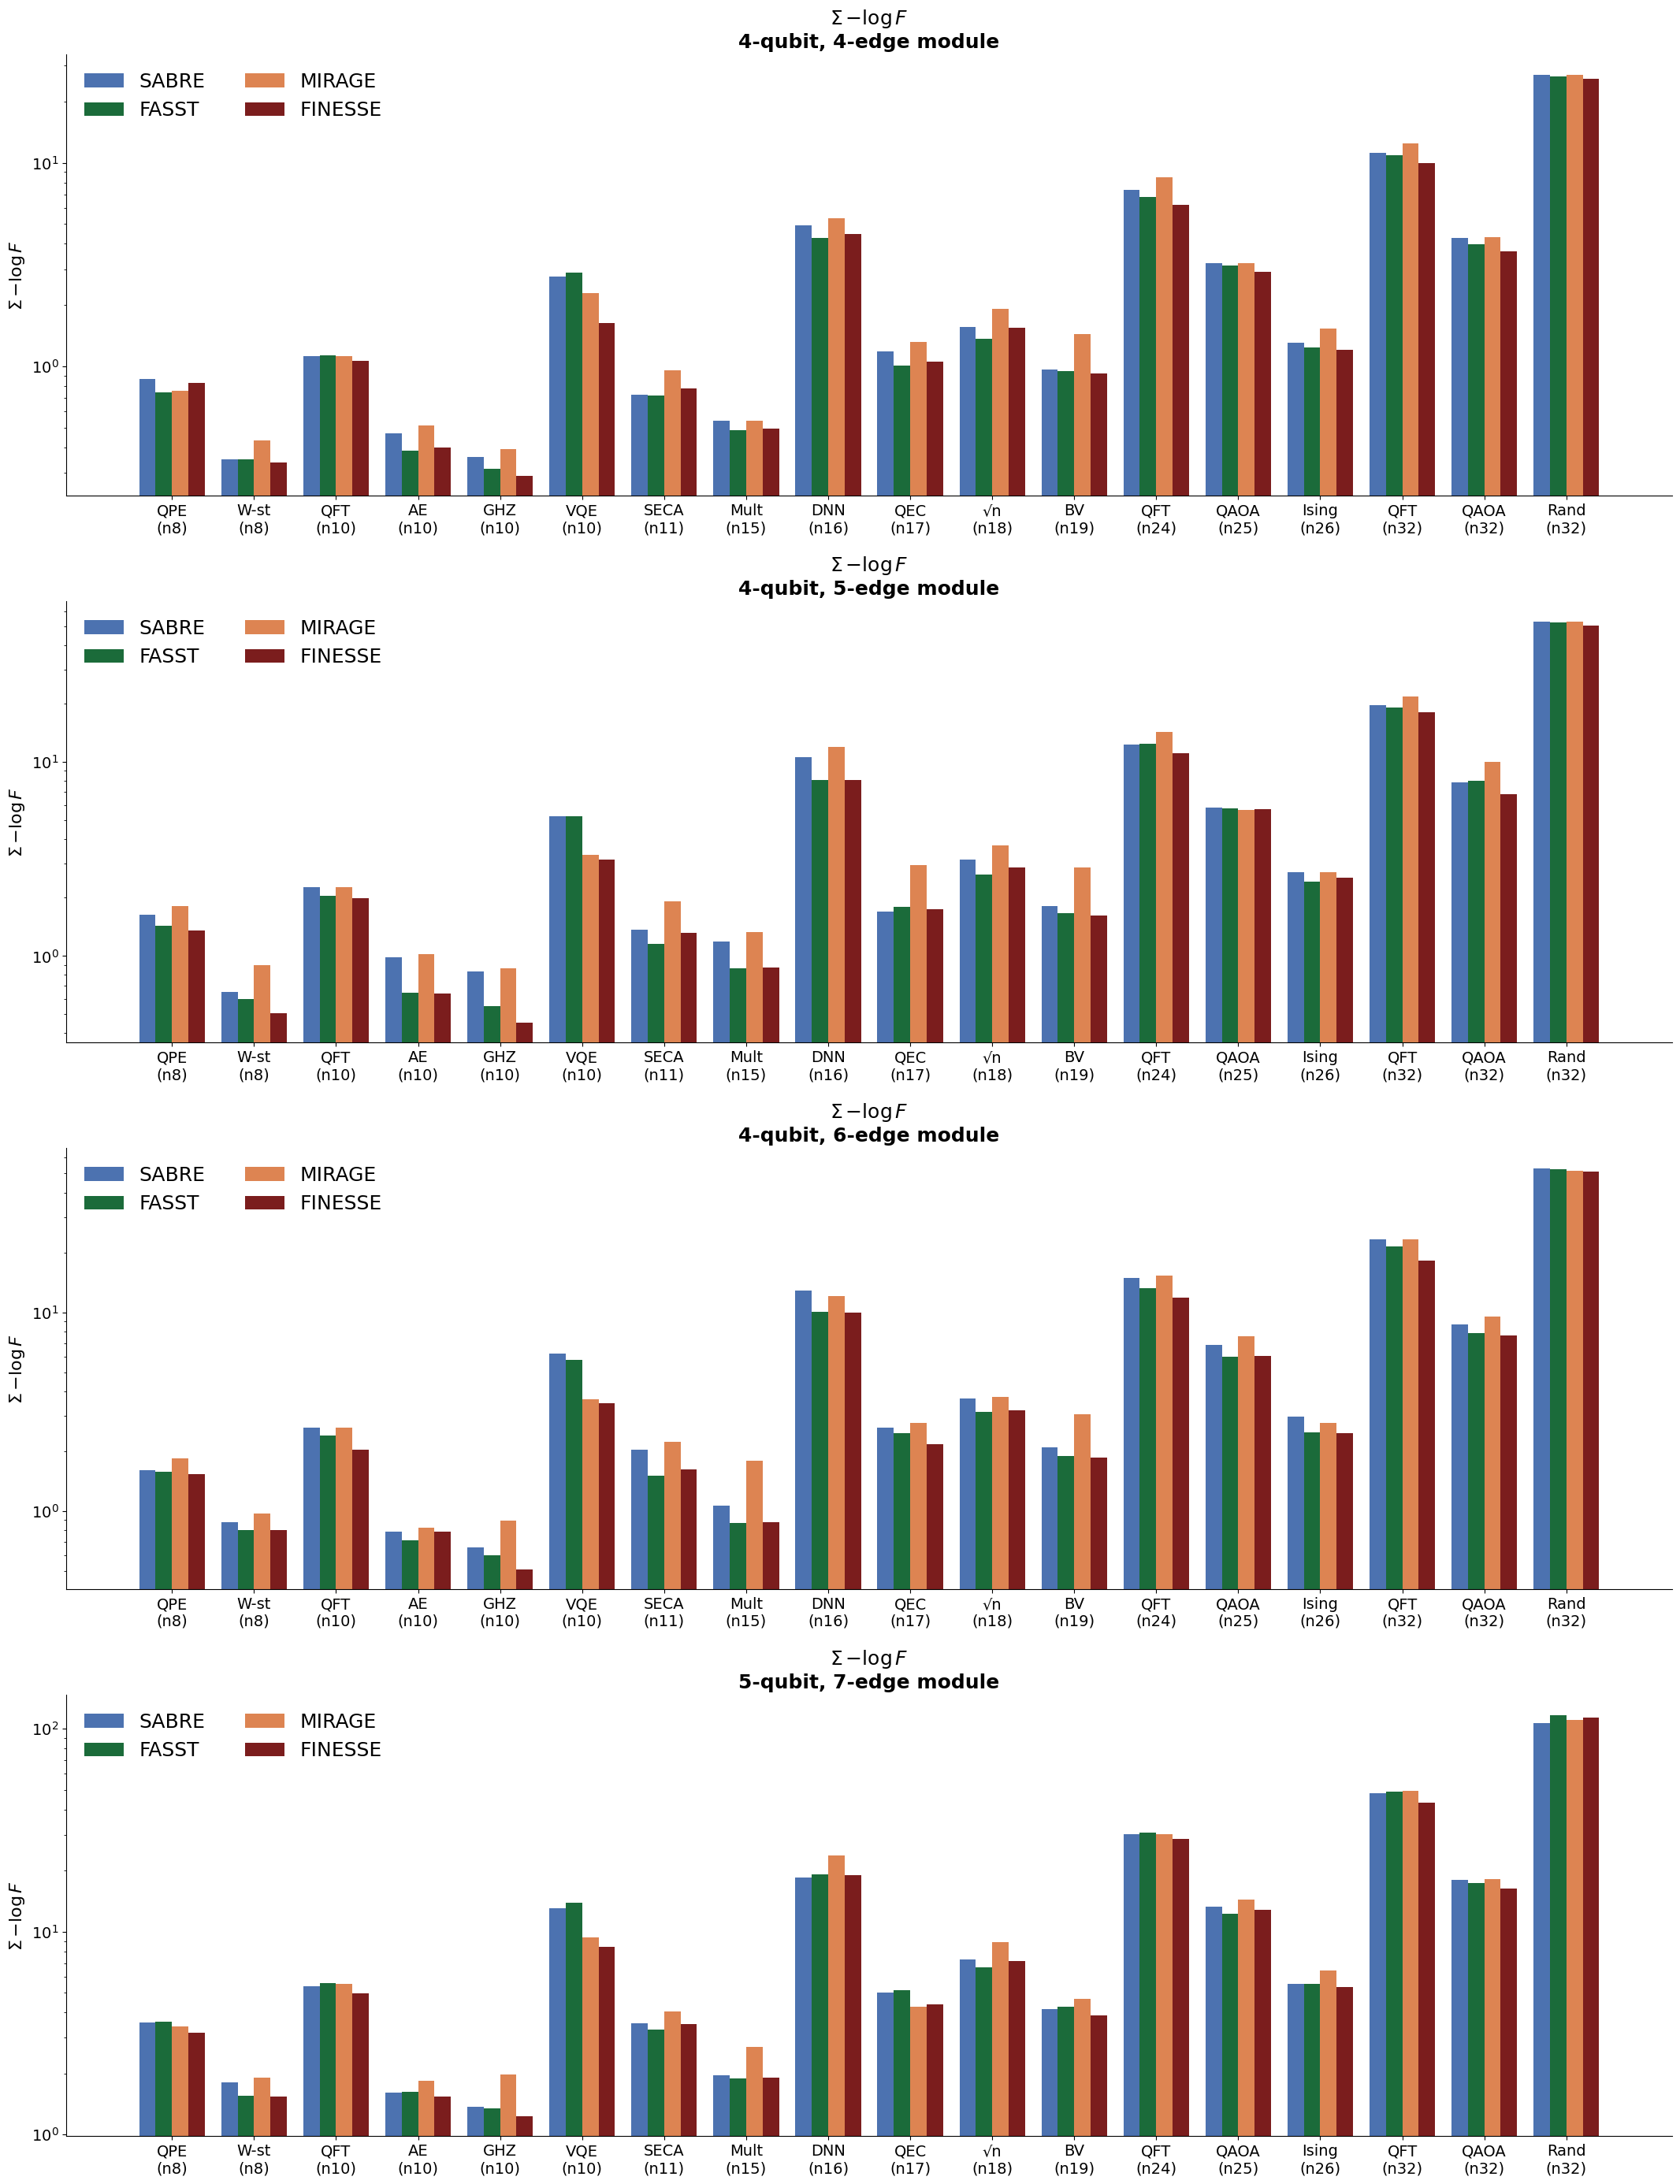

Saved → figures/fig_lf_abs_per_circ_by_topo_native.pdf


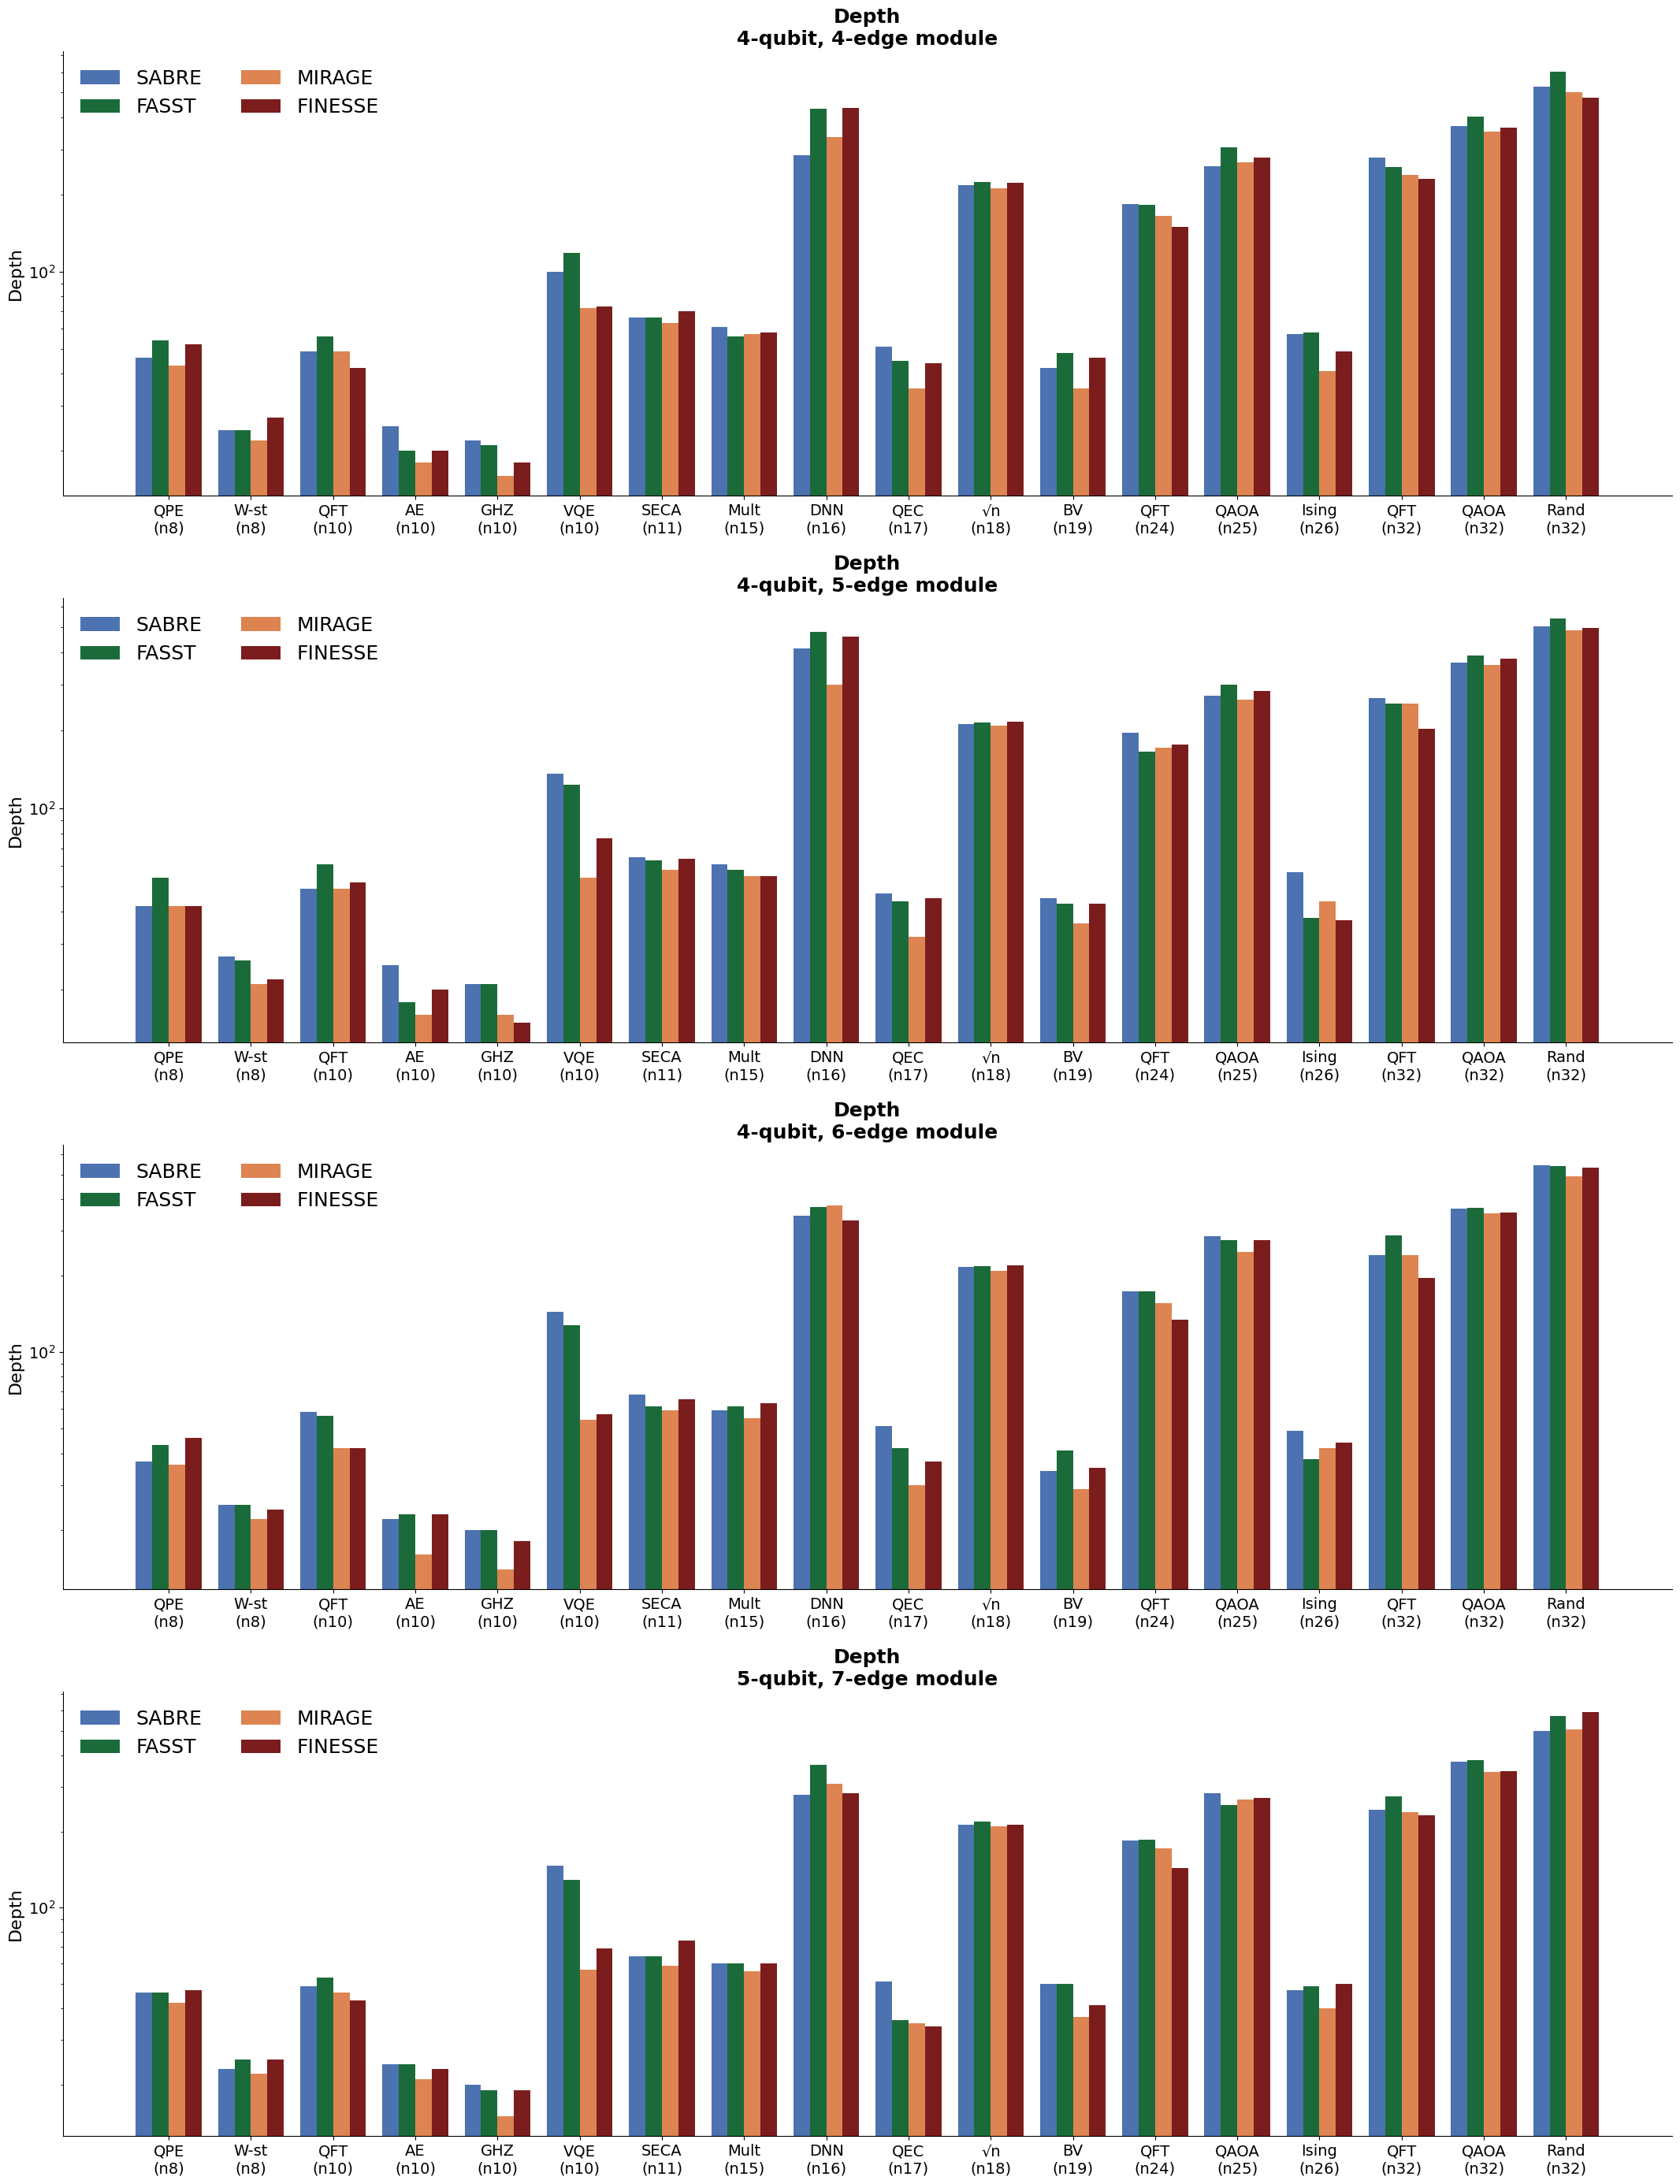

Saved → figures/fig_depth_abs_per_circ_by_topo_native.pdf


In [5]:
ABS_PANELS = [
    ('lf_cost', r'$\Sigma\,{-}\log F$', r'$\Sigma\,{-}\log F$', 'fig_lf_abs_per_circ_by_topo_native.pdf'),
    ('depth',   'Depth',                 'Depth',                 'fig_depth_abs_per_circ_by_topo_native.pdf'),
]

for col, ylabel, title_base, fname in ABS_PANELS:  # removed ymax
    n_topos = len(nowrap_topos)
    ncols = 1
    nrows = n_topos
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(max(10, len(circs) * 1.2), 7 * nrows),
                             sharey=False)
    axes = axes.flatten()

    for ax_idx, topo in enumerate(nowrap_topos):
        ax = axes[ax_idx]
        ax.set_title(f'{title_base}\n{TOPO_LABELS.get(topo, topo)}', fontweight='bold')

        for k, (cfg, color) in enumerate(zip(CONFIG_ORDER, CFG_COLORS)):
            vals = []
            for circ in circs:
                r = ps_df_native[(ps_df_native.topo==topo)&(ps_df_native.circuit==circ)&(ps_df_native.config==cfg)]
                vals.append(float(r[col].values[0]) if len(r) else 0.0)

            ax.bar(xs + (k - (n_cfg4-1)/2)*w4, vals, w4, color=color, label=cfg)
            # removed: bar capping and overflow annotation logic

        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
        ax.set_xticks(xs)
        ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs])
        ax.set_ylabel(ylabel)
        ax.legend(loc='upper left', frameon=False, ncol=2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.set_minor_locator(mticker.LogLocator(subs='auto'))

    for ax_idx in range(len(nowrap_topos), len(axes)):
        axes[ax_idx].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}')

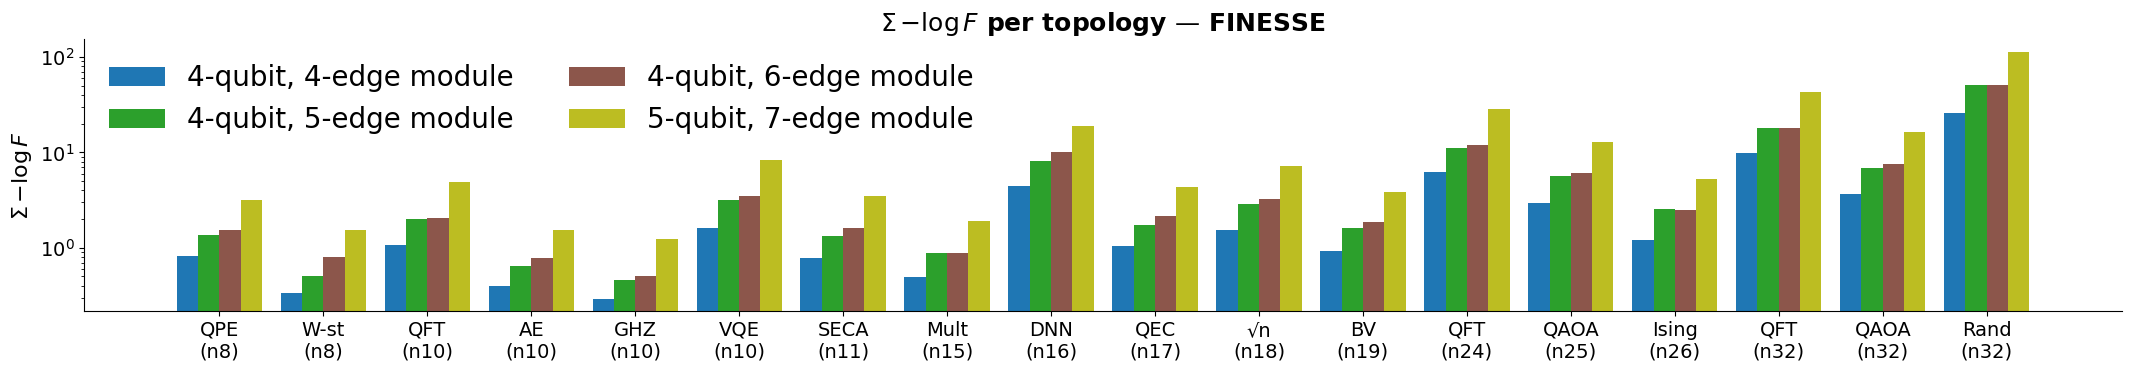

Saved → figures/fig_topo_lf_finesse_native.pdf


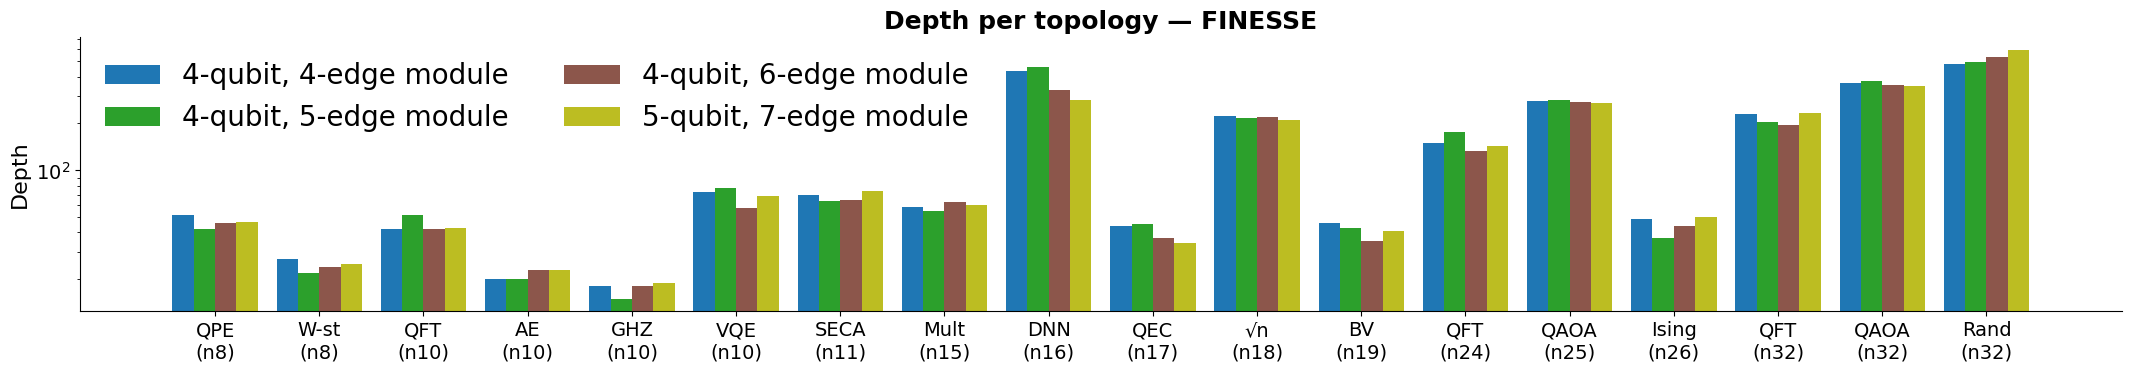

Saved → figures/fig_topo_depth_finesse_native.pdf


In [6]:
# ── Fig: lf cost + depth per topology — FINESSE post-selected, non-wrapped ─────
# → fig_topo_lf_finesse_native.pdf
# → fig_topo_depth_finesse_native.pdf

ps_all_topos = post_select(df[~df['topo'].str.endswith('_wrap')], POST_SELECT_NATIVE)
finesse_tc   = ps_all_topos[ps_all_topos['config'] == 'FINESSE']

circs = [c for c in CIRCUIT_ORDER if c in finesse_tc['circuit'].values]
topos = [t for t in TOPO_ORDER if t in finesse_tc['topo'].values and not t.endswith('_wrap')]
xs    = np.arange(len(circs))
n_t   = len(topos)
w     = 0.82 / n_t

topo_colors = plt.cm.tab10(np.linspace(0, 0.8, n_t))

FINESSE_PANELS = [
    ('lf_cost', r'$\Sigma\,{-}\log F$', r'$\Sigma\,{-}\log F$ per topology — FINESSE', 'fig_topo_lf_finesse_native.pdf'),
    ('depth',   'Depth',                'Depth per topology — FINESSE',                 'fig_topo_depth_finesse_native.pdf'),
]

for col, ylabel, title, fname in FINESSE_PANELS:
    fig, ax = plt.subplots(figsize=(max(8, len(circs) * 1.2), 4))
    ax.set_title(title, fontweight='bold')

    for k, (topo, color) in enumerate(zip(topos, topo_colors)):
        vals = []
        for c in circs:
            r = finesse_tc[(finesse_tc['topo'] == topo) & (finesse_tc['circuit'] == c)]
            vals.append(float(r[col].values[0]) if len(r) else np.nan)
        ax.bar(xs + (k - (n_t-1)/2)*w, vals, w, color=color, label=TOPO_LABELS.get(topo, topo))

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
    ax.yaxis.set_minor_locator(mticker.LogLocator(subs='auto'))
    ax.set_xticks(xs)
    ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs])
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left', frameon=False, ncol=2, fontsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}')

In [ ]:
# ── Fig: absolute lf cost — IBM backends, all 4 configs — log scale ──────────
# → fig_ibm_lf_abs_native.pdf
#
# One subplot per IBM backend; grouped bars per circuit; log scale.

circs_t   = [c for c in CIRCUIT_ORDER if c in ps_dft_native['circuit'].values]
ibm_topos = [t for t in IBM_TOPO_ORDER if t in ps_dft_native['topo'].values]
xs        = np.arange(len(circs_t))
n_cfg4    = len(CONFIG_ORDER)
w4        = 0.80 / n_cfg4

fig, axes = plt.subplots(len(ibm_topos), 1,
                         figsize=(max(10, len(circs_t) * 1.2), 6 * len(ibm_topos)),
                         sharey=False)
axes = np.atleast_1d(axes)

for ax, topo in zip(axes, ibm_topos):
    ax.set_title(IBM_TOPO_LABELS[topo], fontweight='bold')

    for k, (cfg, color) in enumerate(zip(CONFIG_ORDER, CFG_COLORS)):
        vals = []
        for c in circs_t:
            r = ps_dft_native[(ps_dft_native['topo'] == topo) &
                              (ps_dft_native['circuit'] == c) &
                              (ps_dft_native['config'] == cfg)]
            vals.append(float(r['lf_cost'].values[0]) if len(r) else np.nan)
        ax.bar(xs + (k - (n_cfg4-1)/2)*w4, vals, w4, color=color, label=cfg)

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
    ax.yaxis.set_minor_locator(mticker.LogLocator(subs='auto'))
    ax.set_xticks(xs)
    ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs_t])
    ax.set_ylabel(r'$\Sigma\,{-}\log F$')
    ax.legend(loc='upper left', frameon=False, ncol=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(r'$\Sigma\,{-}\log F$ — IBM backends', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_ibm_lf_abs_native.pdf', bbox_inches='tight')
plt.show()
print('Saved → figures/fig_ibm_lf_abs_native.pdf')

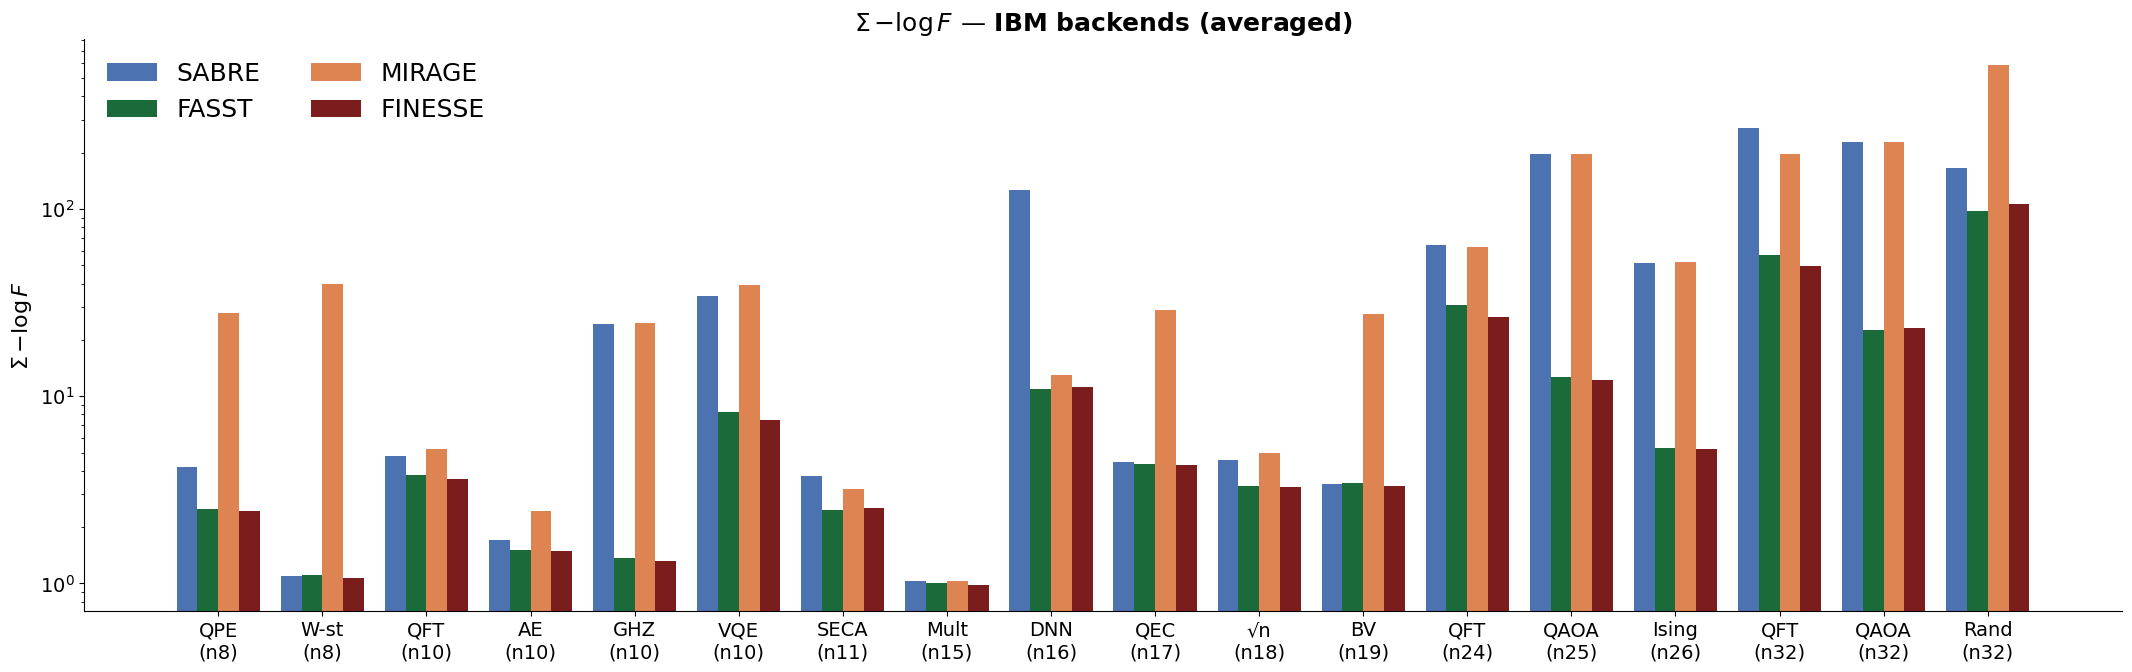

Saved → figures/fig_ibm_lf_abs_avg_native.pdf


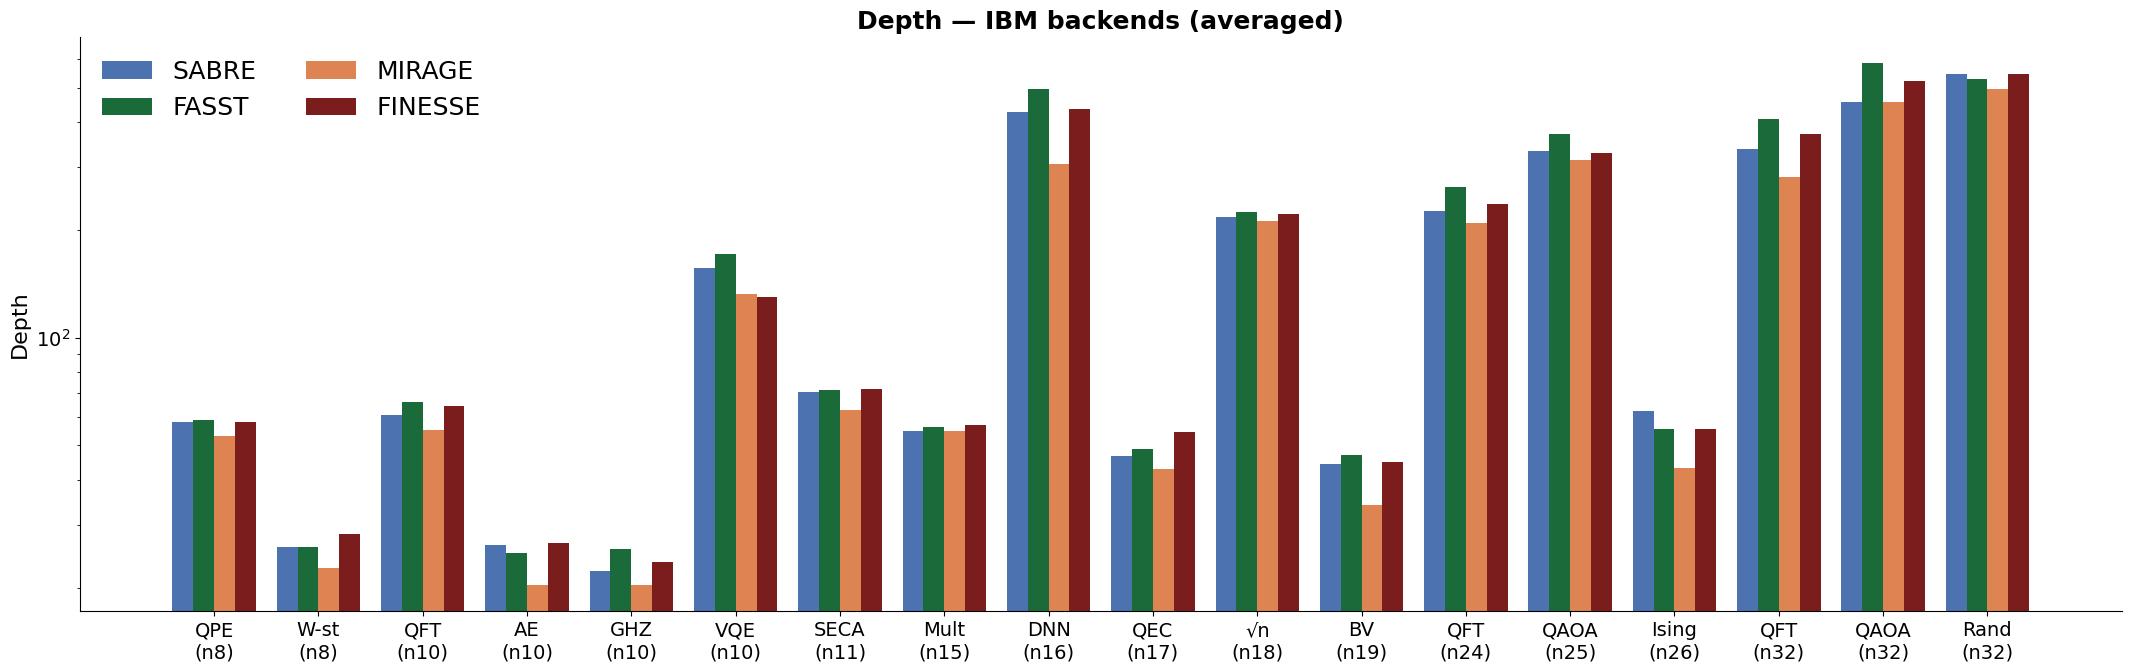

Saved → figures/fig_ibm_depth_abs_avg_native.pdf


In [8]:
# ── Figs: absolute lf cost + depth — IBM, all 4 configs, avg across backends ──
# → fig_ibm_lf_abs_avg_native.pdf
# → fig_ibm_depth_abs_avg_native.pdf
#
# Same format as the SNAIL absolute-values plots: one panel per metric,
# all 4 configs, log scale, averaged across the 3 IBM backends per circuit.

circs_t = [c for c in CIRCUIT_ORDER if c in ps_dft_native['circuit'].values]
xs      = np.arange(len(circs_t))
n_cfg4  = len(CONFIG_ORDER)
w4      = 0.80 / n_cfg4

IBM_ABS_PANELS = [
    ('lf_cost', r'$\Sigma\,{-}\log F$', r'$\Sigma\,{-}\log F$ — IBM backends (averaged)', 'fig_ibm_lf_abs_avg_native.pdf'),
    ('depth',   'Depth',                    'Depth — IBM backends (averaged)',                    'fig_ibm_depth_abs_avg_native.pdf'),
]

for col, ylabel, title, fname in IBM_ABS_PANELS:
    fig, ax = plt.subplots(figsize=(max(10, len(circs_t) * 1.2), 7))
    ax.set_title(title, fontweight='bold')

    for k, (cfg, color) in enumerate(zip(CONFIG_ORDER, CFG_COLORS)):
        vals = []
        for c in circs_t:
            topo_vals = []
            for topo in ibm_topos:
                r = ps_dft_native[(ps_dft_native.topo==topo)&(ps_dft_native.circuit==c)&(ps_dft_native.config==cfg)]
                if len(r):
                    topo_vals.append(float(r[col].values[0]))
            vals.append(np.mean(topo_vals) if topo_vals else np.nan)
        ax.bar(xs + (k - (n_cfg4-1)/2)*w4, vals, w4, color=color, label=cfg)

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(labelOnlyBase=False))
    ax.yaxis.set_minor_locator(mticker.LogLocator(subs='auto'))
    ax.set_xticks(xs)
    ax.set_xticklabels([CIRC_LABELS.get(c, c) for c in circs_t])
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left', frameon=False, ncol=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'figures/{fname}', bbox_inches='tight')
    plt.show()
    print(f'Saved → figures/{fname}')

In [ ]:
# ── Headline numbers — SNAIL, both post-selection modes ───────────────────────

def snail_summary(ps, label):
    rows = []
    for cfg in CONFIG_ORDER:
        lf_vals, sw_vals, d_vals = [], [], []
        for topo in nowrap_topos:
            for circ in present_circs:
                r = ps[(ps.topo==topo)&(ps.circuit==circ)&(ps.config==cfg)]
                if len(r):
                    lf_vals.append(float(r['lf_cost'].iloc[0]))
                    sw_vals.append(float(r['swaps'].iloc[0]))
                    d_vals.append(float(r['depth'].iloc[0]))
        rows.append({'config': cfg,
                     'lf_mean':    np.mean(lf_vals),
                     'swap_mean':  np.mean(sw_vals),
                     'depth_mean': np.mean(d_vals)})
    s = pd.DataFrame(rows).set_index('config')
    for col in ['lf_mean', 'swap_mean', 'depth_mean']:
        base = s.loc['SABRE', col]
        s[col.replace('_mean', '_%_vs_sabre')] = 100 * (s[col] - base) / base
    print(f'=== SNAIL (non-wrapped, averaged over circuits & topologies) — {label} ===\n')
    print(s[['lf_mean','lf_%_vs_sabre','swap_mean','swap_%_vs_sabre','depth_mean','depth_%_vs_sabre']].round(3).to_string())
    print()

snail_summary(ps_df_native, 'native post-selection (SABRE→swaps, MIRAGE→depth, FASST/FINESSE→lf_cost)')
snail_summary(ps_df,        'lf post-selection (all configs→min lf_cost)')

In [ ]:
# ── Headline numbers — IBM (Brooklyn), both post-selection modes ──────────────

def ibm_summary(ps, label):
    ibm_circs = [c for c in CIRCUIT_ORDER if c in ps['circuit'].values]
    rows = []
    for cfg in CONFIG_ORDER:
        lf_vals, sw_vals, d_vals = [], [], []
        for circ in ibm_circs:
            r = ps[(ps.topo=='fake_brooklyn')&(ps.circuit==circ)&(ps.config==cfg)]
            if len(r):
                lf_vals.append(float(r['lf_cost'].iloc[0]))
                sw_vals.append(float(r['swaps'].iloc[0]))
                d_vals.append(float(r['depth'].iloc[0]))
        rows.append({'config': cfg,
                     'lf_mean':    np.mean(lf_vals) if lf_vals else np.nan,
                     'swap_mean':  np.mean(sw_vals) if sw_vals else np.nan,
                     'depth_mean': np.mean(d_vals)  if d_vals  else np.nan})
    s = pd.DataFrame(rows).set_index('config')
    for col in ['lf_mean', 'swap_mean', 'depth_mean']:
        base = s.loc['SABRE', col]
        s[col.replace('_mean', '_%_vs_sabre')] = 100 * (s[col] - base) / base
    print(f'=== IBM — Brooklyn (65q) — {label} ===\n')
    print(s[['lf_mean','lf_%_vs_sabre','swap_mean','swap_%_vs_sabre','depth_mean','depth_%_vs_sabre']].round(3).to_string())
    print()

ibm_summary(ps_dft_native, 'native post-selection (SABRE→swaps, MIRAGE→depth, FASST/FINESSE→lf_cost)')
ibm_summary(ps_dft,        'lf post-selection (all configs→min lf_cost)')

In [ ]:
# ── Beta grid search: choosing the fidelity blend parameter ───────────────────
#
# FINESSE uses D' = α·D_hop + β·D_fid as its routing distance.
# We fix α=1 and sweep β ∈ {0,1,5,10,20,33,100} plus pure fidelity (α=0,β=1).
# 24 seeds per (device, circuit, β) on SNAIL and IBM (Toronto + Sydney).
#
# KEY RESULT: β=1 is the best default across both platforms.
#
# EQUIVALENCE WITH PRIOR RUNS:
#   Old parameterisation used fidelity_blend=0.5:
#       D' = (1-0.5)·D_hop + 0.5·D_fid = 0.5·D_hop + 0.5·D_fid
#   New α=1, β=1:
#       D' = 1·D_hop + 1·D_fid
#   Only the ratio α/β matters for routing decisions (the heuristic picks argmin).
#   These are identical up to a uniform scale factor of 2 → same routing decisions.
#   The 64-seed paper runs (paper.csv, ibm.csv) used fidelity_blend=0.5 and are
#   therefore exactly equivalent to β=1. No rerun is needed.

dg  = pd.read_csv('Results/grid_snail.csv')
dgi = pd.read_csv('Results/grid_ibm.csv')

BETA_ORDER = [0.0, 1.0, 5.0, 10.0, 20.0, 33.0, 100.0]

def grid_summary(df, label, devices=None):
    if devices is not None:
        df = df[df.device.isin(devices)]
    nat_frames, lf_frames = [], []
    for keys, sub in df.groupby(['device','circuit','router','alpha','beta'], dropna=False):
        col = 'swaps' if keys[2] == 'SABRE' else 'lf_cost'
        nat_frames.append(sub.sort_values(col).drop_duplicates(subset=['device','circuit'], keep='first'))
        lf_frames.append(sub.sort_values('lf_cost').drop_duplicates(subset=['device','circuit'], keep='first'))
    ps_nat = pd.concat(nat_frames)
    ps_lf  = pd.concat(lf_frames)

    sabre_nat = ps_nat[ps_nat.router=='SABRE'].set_index(['device','circuit'])['lf_cost']
    sabre_lf  = ps_lf[ps_lf.router =='SABRE'].set_index(['device','circuit'])['lf_cost']

    print(f'=== {label} — FINESSE vs SABRE (lf_cost % change) ===')
    print(f'  {"beta":>6}  {"native ps":>10}  {"lf ps":>10}')
    print('  ' + '-'*32)
    for b in BETA_ORDER:
        m = ps_nat[(ps_nat.router=='FINESSE')&(ps_nat.alpha==1.0)&(ps_nat.beta==b)].set_index(['device','circuit'])['lf_cost']
        l = ps_lf[(ps_lf.router =='FINESSE')&(ps_lf.alpha ==1.0)&(ps_lf.beta ==b)].set_index(['device','circuit'])['lf_cost']
        common = sabre_nat.index.intersection(m.index)
        if common.empty: continue
        pn = 100*(m[common]-sabre_nat[common])/sabre_nat[common]
        pl = 100*(l[common]-sabre_lf[common])/sabre_lf[common]
        marker = '  ← β=1 (chosen default, equiv. to old fidelity_blend=0.5)' if b == 1.0 else ''
        print(f'  {b:>6.0f}  {pn.mean():>+9.1f}%  {pl.mean():>+9.1f}%{marker}')
    # pure fidelity ablation
    m = ps_nat[(ps_nat.router=='FINESSE')&(ps_nat.alpha==0.0)&(ps_nat.beta==1.0)].set_index(['device','circuit'])['lf_cost']
    l = ps_lf[(ps_lf.router =='FINESSE')&(ps_lf.alpha ==0.0)&(ps_lf.beta ==1.0)].set_index(['device','circuit'])['lf_cost']
    common = sabre_nat.index.intersection(m.index)
    if not common.empty:
        pn = 100*(m[common]-sabre_nat[common])/sabre_nat[common]
        pl = 100*(l[common]-sabre_lf[common])/sabre_lf[common]
        print(f'  {"a0b1":>6}  {pn.mean():>+9.1f}%  {pl.mean():>+9.1f}%  ← pure fidelity (no hop count)')
    print()

grid_summary(dg,  'SNAIL (24 seeds, 4 topologies, 6 circuits)')
grid_summary(dgi, 'IBM (24 seeds, Toronto + Sydney only)', devices=['fake_toronto','fake_sydney'])

print('Rationale for β=1:')
print('  · Best or near-best on every SNAIL topology and IBM backend')
print('  · High β (≥10) helps some SNAIL topologies but degrades IBM and pentagon_ring')
print('  · Pure fidelity (α=0) loses directional signal on large circuits (qft_n24 +14.5%)')
print('  · β=1 is equivalent to the original fidelity_blend=0.5 — prior 64-seed runs are valid')